In [ ]:
#Fetching data from yfinance

In [2]:
import yfinance as yf

aapl= yf.Ticker("aapl")
aapl

yfinance.Ticker object <AAPL>

In [12]:
aapl_historical = aapl.history(start="2021-01-01", end="2025-10-03", interval="1d")
aapl_historical

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-01-04 00:00:00-05:00,130.101364,130.189056,123.514445,126.096596,143301900,0.0,0.0
2021-01-05 00:00:00-05:00,125.589924,128.366960,125.141696,127.655640,97664900,0.0,0.0
2021-01-06 00:00:00-05:00,124.449847,127.694587,123.144152,123.358521,155088000,0.0,0.0
2021-01-07 00:00:00-05:00,125.073481,128.259760,124.586283,127.567932,109578200,0.0,0.0
2021-01-08 00:00:00-05:00,129.039267,129.234158,126.895598,128.669006,105158200,0.0,0.0
...,...,...,...,...,...,...,...
2025-09-26 00:00:00-04:00,254.100006,257.600006,253.779999,255.460007,46076300,0.0,0.0
2025-09-29 00:00:00-04:00,254.559998,255.000000,253.009995,254.429993,40127700,0.0,0.0
2025-09-30 00:00:00-04:00,254.860001,255.919998,253.110001,254.630005,37704300,0.0,0.0


In [14]:
aapl_historical.to_csv("Apple3.csv")

print("CSV file saved successfully as 'Apple3.csv'")

CSV file saved successfully as 'Apple3.csv'


In [ ]:
#Reading csv file

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Load and preview data
df = pd.read_csv("Apple1.csv")  # Example name
df.head()

In [204]:
# Drop 'Dividends' and 'Stock Splits'
df = df.drop(columns=['Dividends', 'Stock Splits'])

In [206]:
df.head()

,Date,Open,High,Low,Close,Volume
0,2021-01-04 00:00:00-05:00,130.101364,130.189056,123.514445,126.096596,143301900
1,2021-01-05 00:00:00-05:00,125.589864,128.366898,125.141636,127.655579,97664900
2,2021-01-06 00:00:00-05:00,124.449862,127.694603,123.144167,123.358536,155088000
3,2021-01-07 00:00:00-05:00,125.073466,128.259745,124.586268,127.567917,109578200
4,2021-01-08 00:00:00-05:00,129.039221,129.234112,126.895553,128.668961,105158200


In [208]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1193 entries, 0 to 1192
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1193 non-null   object 
 1   Open    1193 non-null   float64
 2   High    1193 non-null   float64
 3   Low     1193 non-null   float64
 4   Close   1193 non-null   float64
 5   Volume  1193 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 56.1+ KB
None


In [210]:
print(df.describe())

              Open         High          Low        Close        Volume
count  1193.000000  1193.000000  1193.000000  1193.000000  1.193000e+03
mean    174.890360   176.809007   173.151672   175.075184  7.109015e+07
std      35.328140    35.580185    35.120768    35.401375  2.990392e+07
min     116.155679   117.492580   113.403761   113.550140  2.323470e+07
25%     145.553877   147.022337   144.124563   145.759430  4.951470e+07
50%     170.212802   171.945817   168.785230   170.665619  6.458890e+07
75%     201.201646   203.209377   199.233893   200.852051  8.592800e+07
max     257.276679   259.179926   256.718662   258.103729  3.186799e+08


In [212]:
print(df.isnull().sum())

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


In [214]:
df.shape

(1193, 6)

In [216]:
df['Date'] = pd.to_datetime(df['Date'], utc=True)  # parse with UTC
df['Date'] = df['Date'].dt.tz_convert(None)        # remove timezone, make naive


In [218]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1193 entries, 0 to 1192
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1193 non-null   datetime64[ns]
 1   Open    1193 non-null   float64       
 2   High    1193 non-null   float64       
 3   Low     1193 non-null   float64       
 4   Close   1193 non-null   float64       
 5   Volume  1193 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 56.1 KB


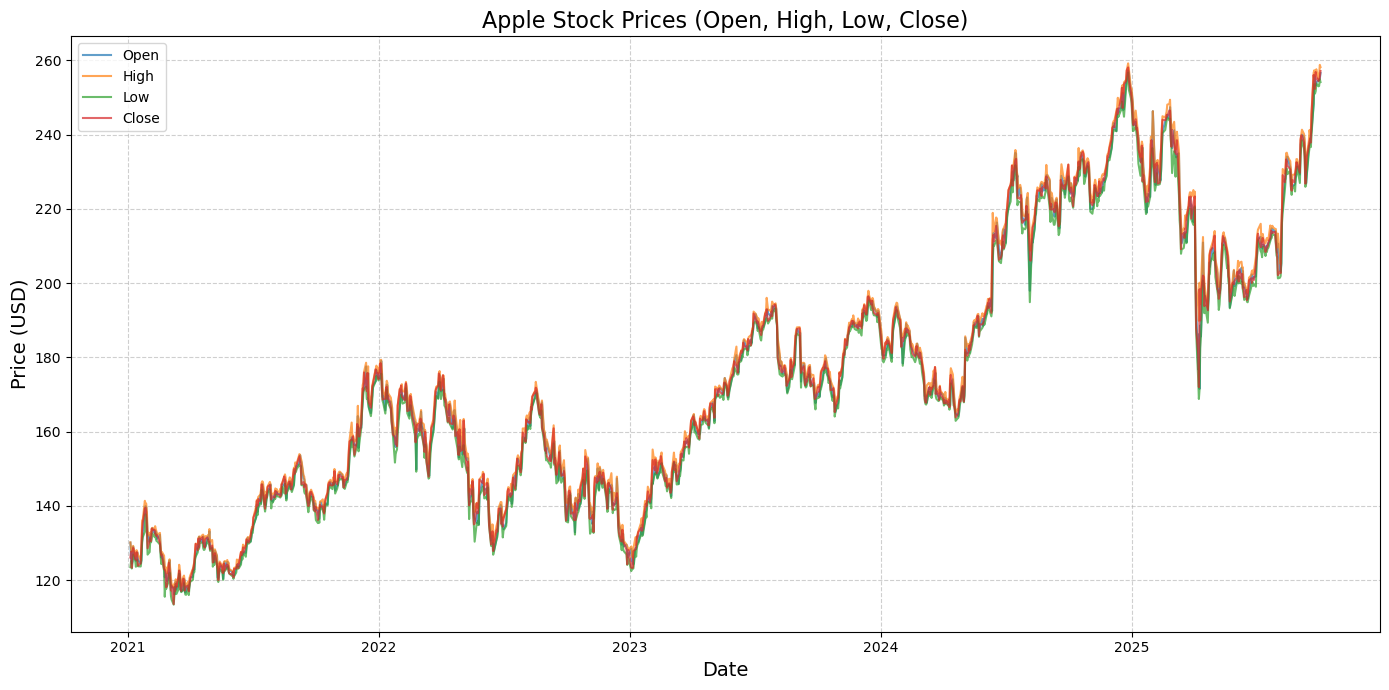

In [220]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

price_cols = ['Open', 'High', 'Low', 'Close']

plt.figure(figsize=(14,7))
for col in price_cols:
    plt.plot(df['Date'], df[col], label=col, alpha=0.7)

plt.title('Apple Stock Prices (Open, High, Low, Close)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Price (USD)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()


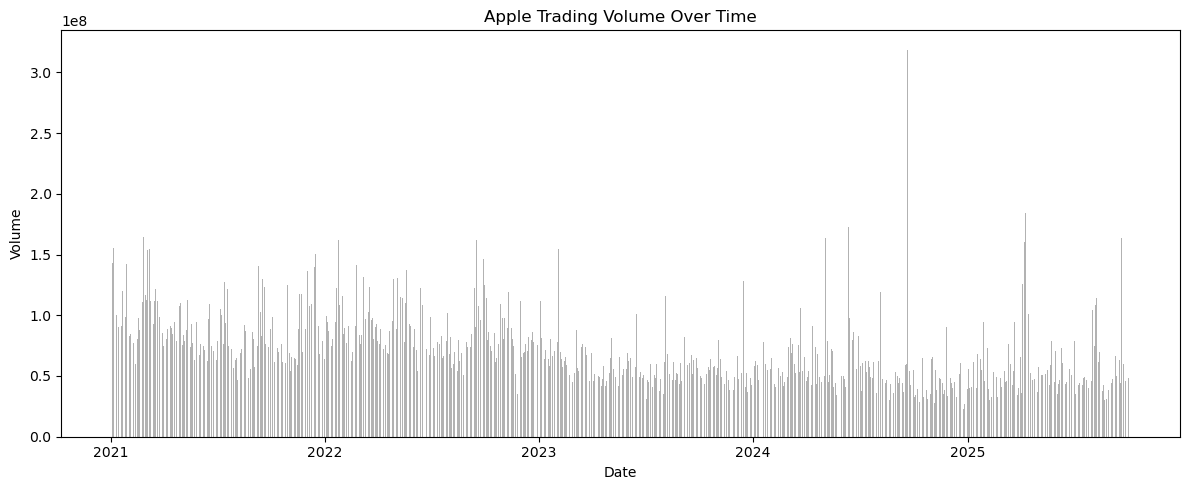

In [221]:
plt.figure(figsize=(12,5))
plt.bar(df['Date'], df['Volume'], color='gray', alpha=0.6)
plt.title('Apple Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()


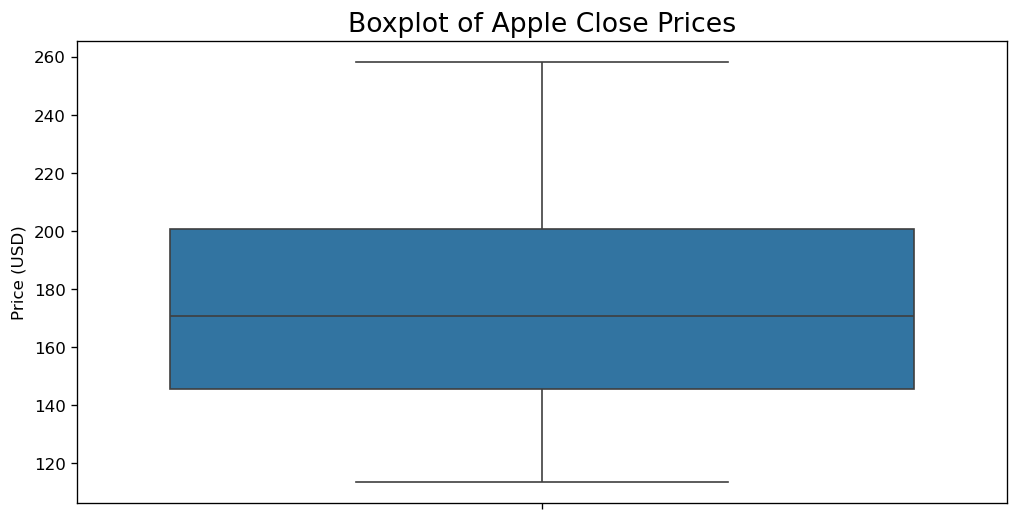

In [248]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(y=df['Close'])
plt.title('Boxplot of Apple Close Prices', fontsize=16)
plt.ylabel('Price (USD)')
plt.show()


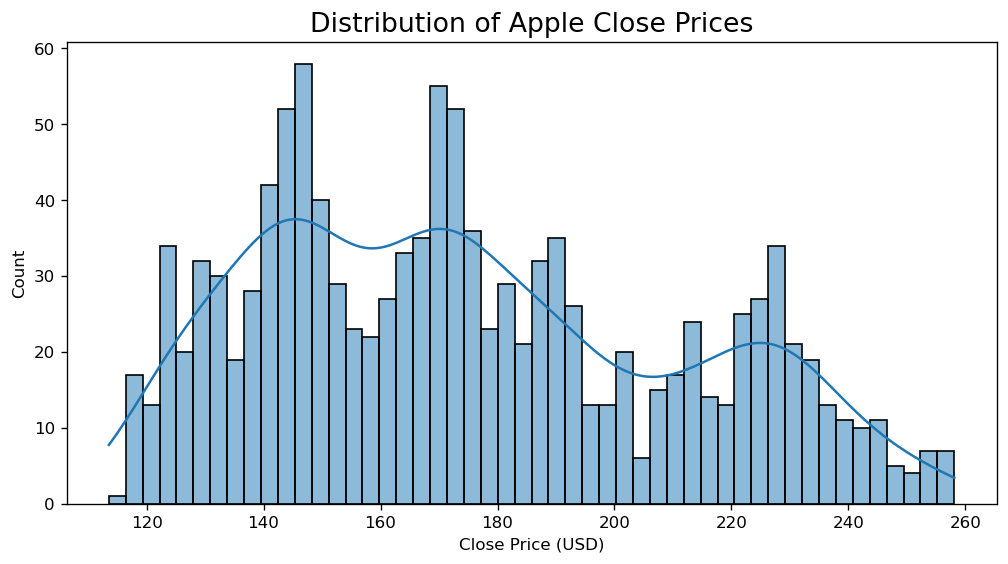

In [250]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df['Close'], bins=50, kde=True)
plt.title('Distribution of Apple Close Prices', fontsize=16)
plt.xlabel('Close Price (USD)')
plt.show()


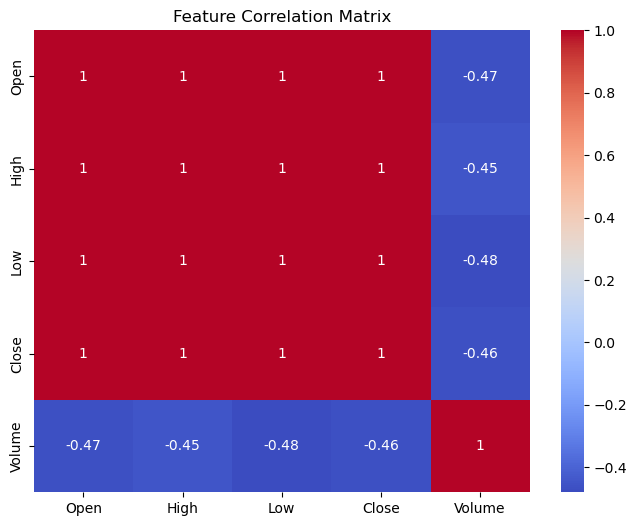

In [222]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Open','High','Low','Close','Volume']].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()


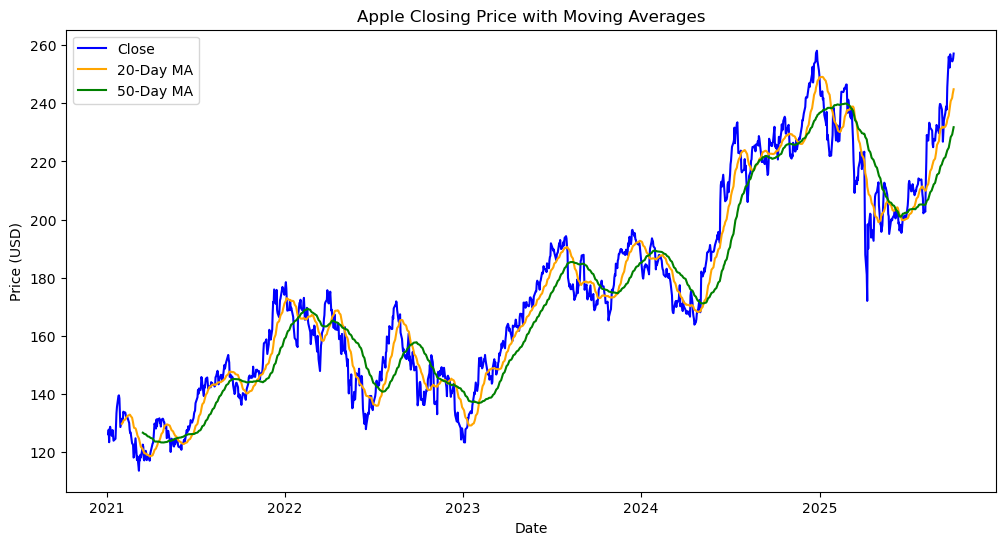

In [224]:
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Close', color='blue')
plt.plot(df['Date'], df['MA20'], label='20-Day MA', color='orange')
plt.plot(df['Date'], df['MA50'], label='50-Day MA', color='green')
plt.title('Apple Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()


In [225]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
df['Date'] = pd.to_datetime(df['Date'])
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.strftime('%b')  # 'Jan', 'Feb', etc.
years = df['year'].unique()

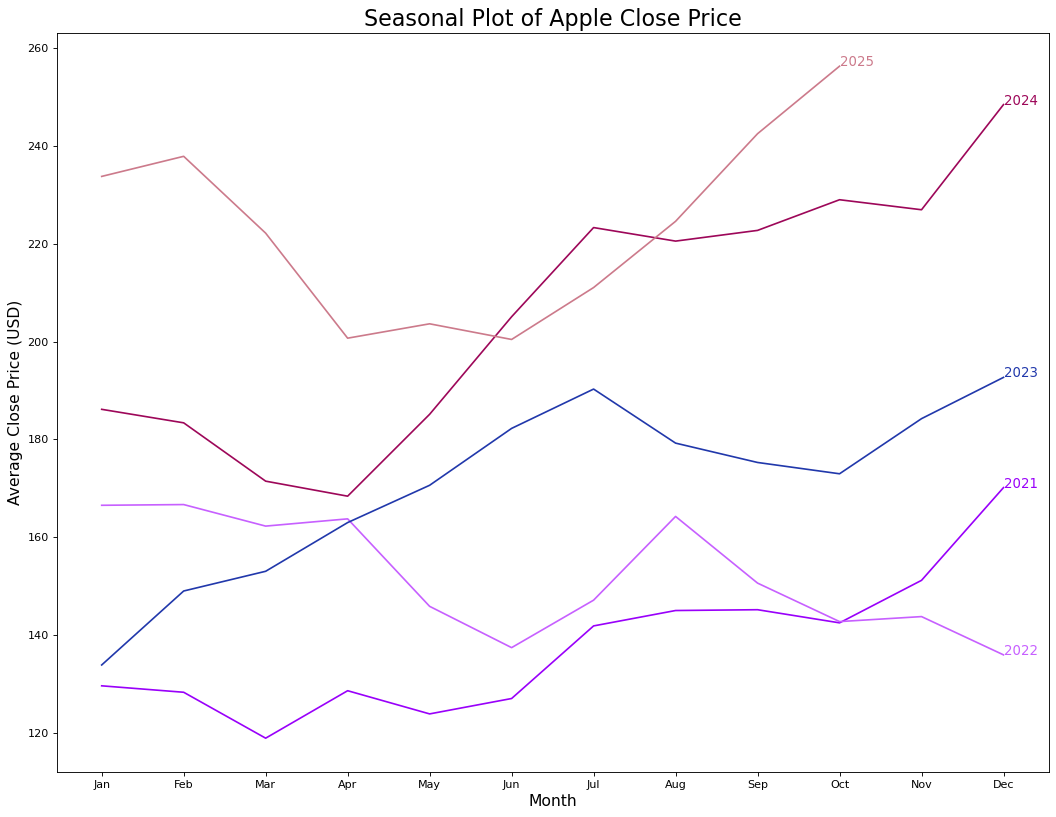

In [230]:
plt.figure(figsize=(16,12), dpi=80)

for i, y in enumerate(years):
    data_year = df[df['year'] == y]
    monthly_avg = data_year.groupby('month')['Close'].mean()
    
    months_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    monthly_avg = monthly_avg.reindex(months_order)
    
    plt.plot(months_order, monthly_avg, color=mycolors[i], label=y)
    
    # Get last non-NaN month for labeling
    last_month = monthly_avg.last_valid_index()
    if last_month is not None:
        plt.text(last_month, monthly_avg[last_month], str(y), fontsize=12, color=mycolors[i])

plt.xlabel('Month', fontsize=14)
plt.ylabel('Average Close Price (USD)', fontsize=14)
plt.title('Seasonal Plot of Apple Close Price', fontsize=20)
plt.show()


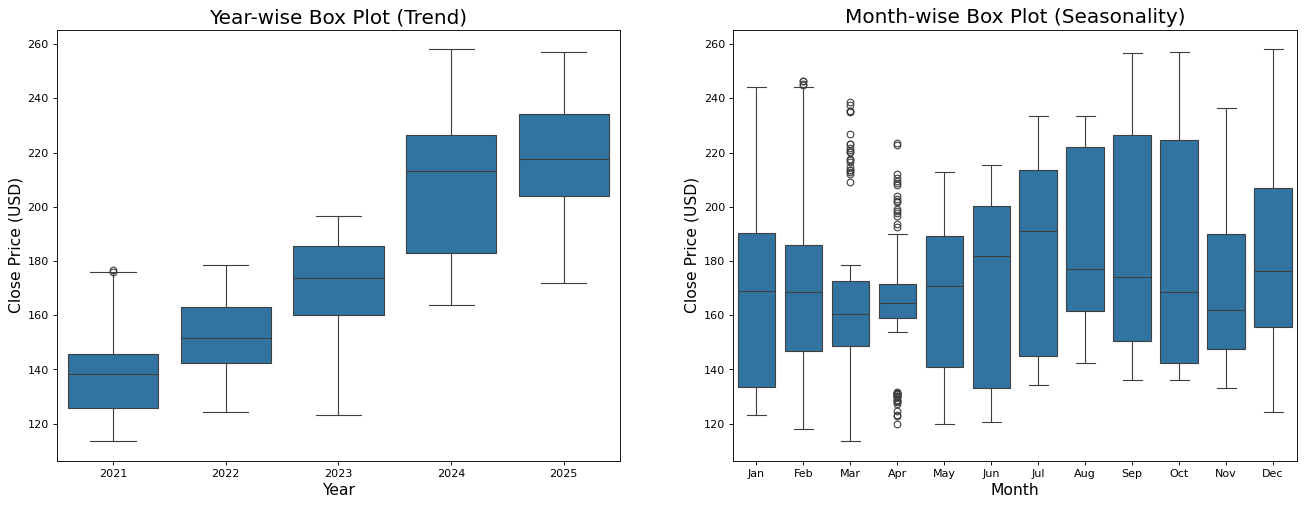

In [232]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming df['Date'] is already datetime64[ns]
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.strftime('%b')  # Jan, Feb, etc.

# Optional: order months correctly
months_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Draw side-by-side boxplots
fig, axes = plt.subplots(1, 2, figsize=(20,7), dpi=80)

# Year-wise boxplot (trend)
sns.boxplot(x='year', y='Close', data=df, ax=axes[0])
axes[0].set_title('Year-wise Box Plot (Trend)', fontsize=18)
axes[0].set_xlabel('Year', fontsize=14)
axes[0].set_ylabel('Close Price (USD)', fontsize=14)

# Month-wise boxplot (seasonality)
sns.boxplot(x='month', y='Close', data=df, ax=axes[1], order=months_order)
axes[1].set_title('Month-wise Box Plot (Seasonality)', fontsize=18)
axes[1].set_xlabel('Month', fontsize=14)
axes[1].set_ylabel('Close Price (USD)', fontsize=14)

plt.show()


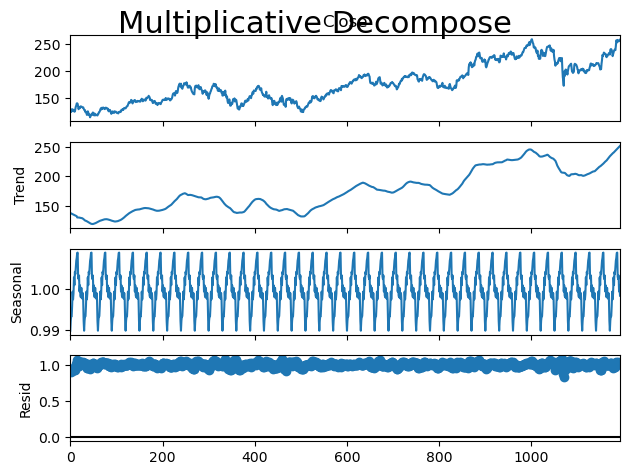

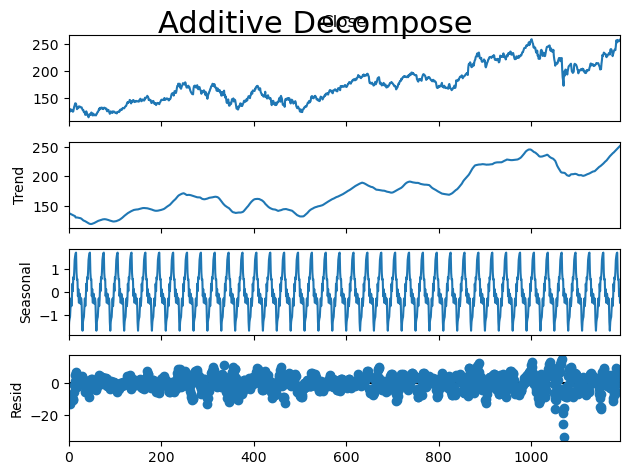

In [234]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Use Close column only, specify period
result_mul = seasonal_decompose(df['Close'], model='multiplicative', period=30, extrapolate_trend='freq')
result_add = seasonal_decompose(df['Close'], model='additive', period=30, extrapolate_trend='freq')

# Plot
result_mul.plot().suptitle('Multiplicative Decompose', fontsize=22)
result_add.plot().suptitle('Additive Decompose', fontsize=22)
plt.show()




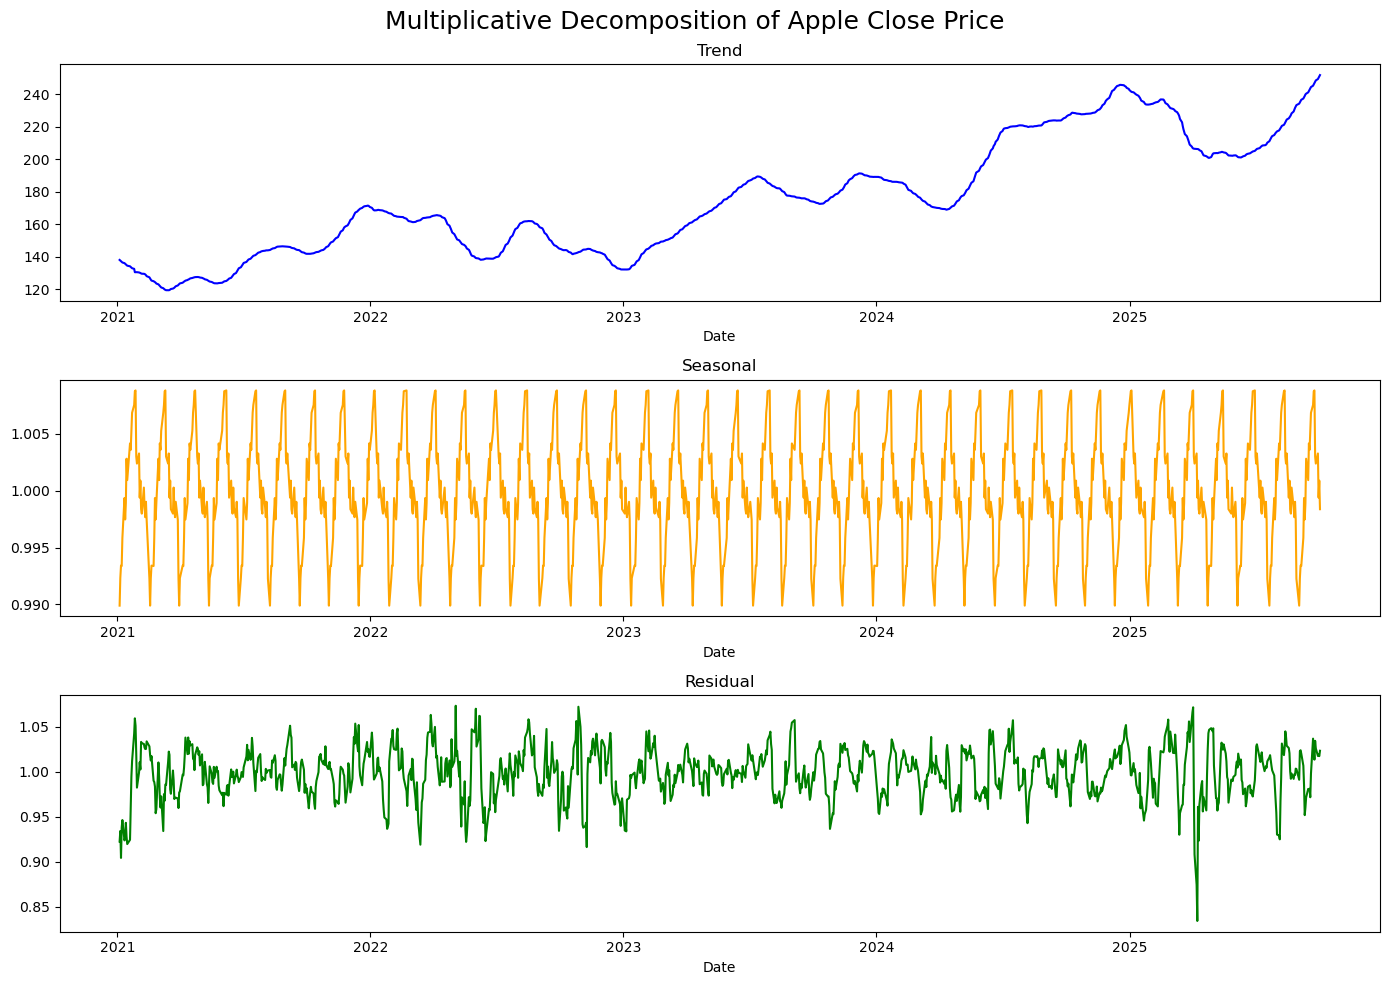

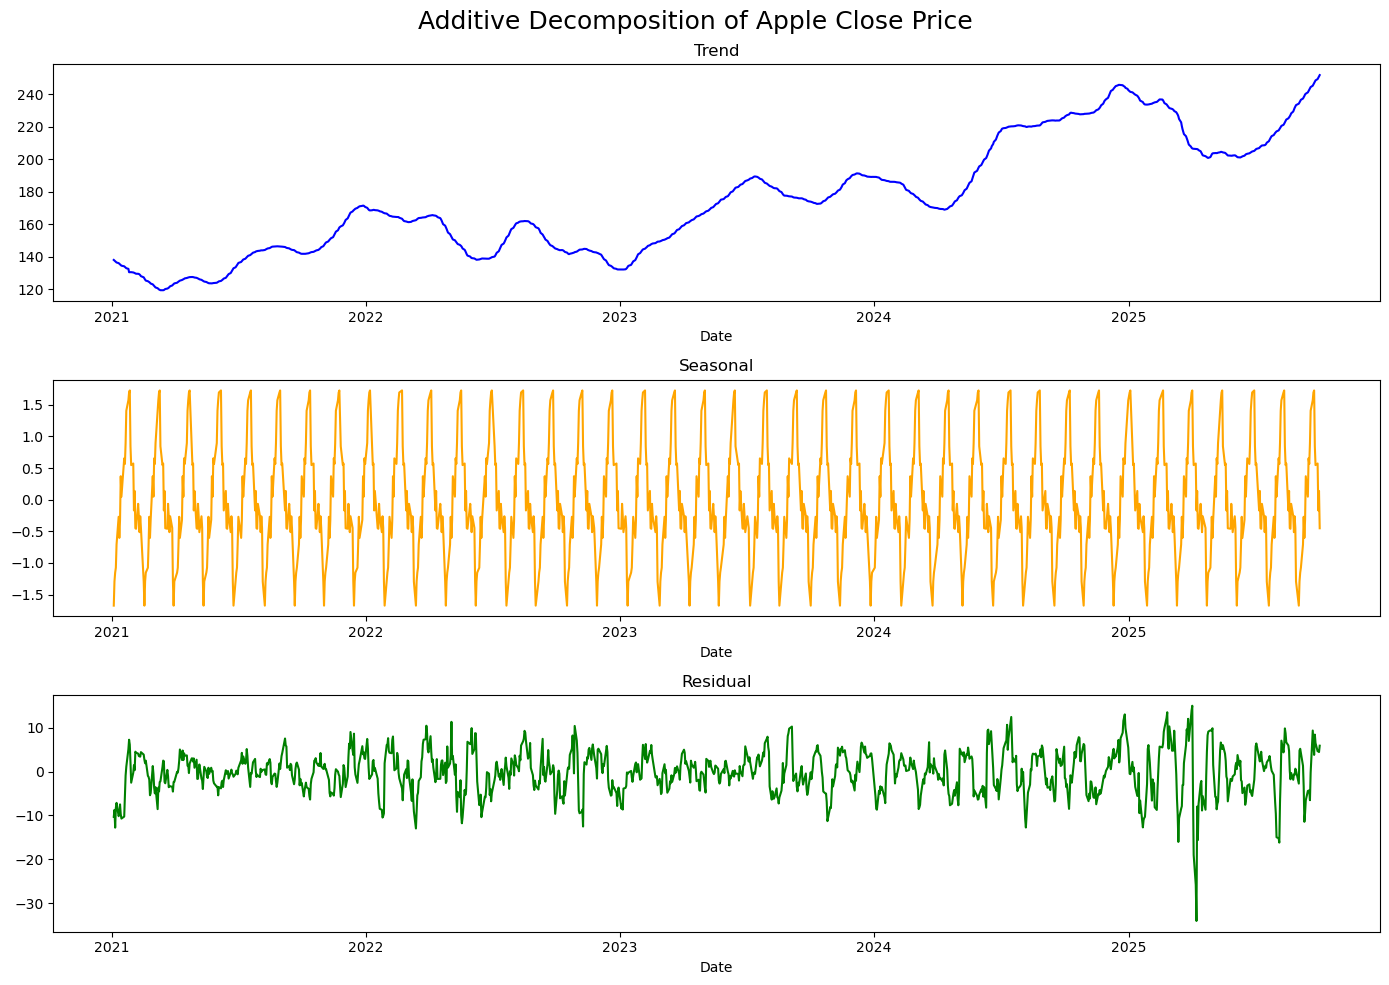

In [236]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Copy the DataFrame so original is intact
df_temp = df.copy()
df_temp['Date'] = pd.to_datetime(df_temp['Date'])  # ensure datetime

# Decomposition period (approx. monthly)
period = 30  # 30 trading days ≈ 1 month

# Perform decomposition without setting daily frequency
result_mul = seasonal_decompose(df_temp['Close'], model='multiplicative', period=period, extrapolate_trend='freq')
result_add = seasonal_decompose(df_temp['Close'], model='additive', period=period, extrapolate_trend='freq')

# Function to plot decomposition with actual trading dates
def plot_decomposition(dates, result, title):
    plt.figure(figsize=(14,10))

    plt.subplot(3,1,1)
    plt.plot(dates, result.trend, color='blue')
    plt.title('Trend')
    plt.xlabel('Date')

    plt.subplot(3,1,2)
    plt.plot(dates, result.seasonal, color='orange')
    plt.title('Seasonal')
    plt.xlabel('Date')

    plt.subplot(3,1,3)
    plt.plot(dates, result.resid, color='green')
    plt.title('Residual')
    plt.xlabel('Date')

    plt.suptitle(title, fontsize=18)
    plt.tight_layout()
    plt.show()

# Plot multiplicative decomposition
plot_decomposition(df_temp['Date'], result_mul, 'Multiplicative Decomposition of Apple Close Price')

# Plot additive decomposition
plot_decomposition(df_temp['Date'], result_add, 'Additive Decomposition of Apple Close Price')


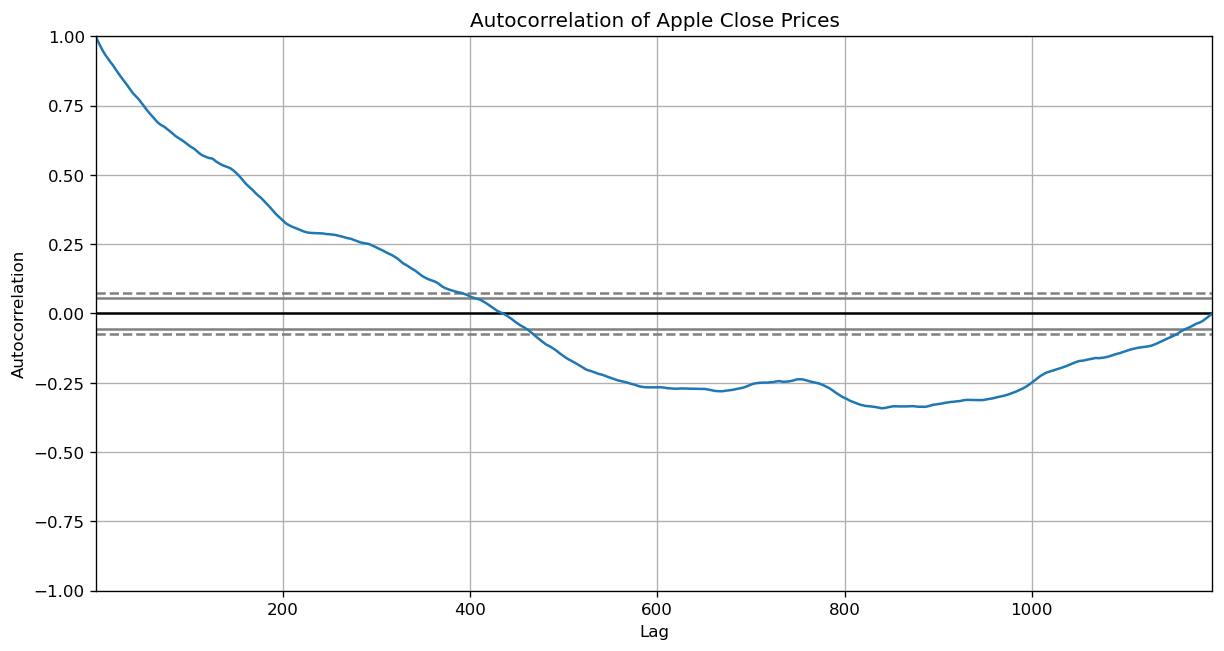

In [246]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import autocorrelation_plot

# Draw ACF plot for Close prices
plt.rcParams.update({'figure.figsize': (12,6), 'figure.dpi': 120})
autocorrelation_plot(df['Close'].tolist())

plt.title("Autocorrelation of Apple Close Prices")
plt.show()


In [ ]:
#Stationarity check

In [240]:
from statsmodels.tsa.stattools import adfuller, kpss

# Apple Close column
close_values = df['Close'].values

# Augmented Dickey-Fuller test (null: non-stationary)
adf_result = adfuller(close_values, autolag='AIC')
print("ADF Test:")
print(f"  Statistic: {adf_result[0]}")
print(f"  p-value: {adf_result[1]}")
print("  Critical Values:")
for key, value in adf_result[4].items():
    print(f"    {key}: {value}")


if adf_result[1] < 0.05:
    print("\nNull hypothesis rejected: Series is likely stationary.")
else:
    print("\nNull hypothesis NOT rejected: Series is non-stationary.")



ADF Test:
  Statistic: -0.9332207940288704
  p-value: 0.7768356079841807
  Critical Values:
    1%: -3.4358478507713777
    5%: -2.863967751840151
    10%: -2.568062580992973

Null hypothesis NOT rejected: Series is non-stationary.


In [244]:
# KPSS test (null: stationary)
kpss_result = kpss(close_values, regression='c')
print("\nKPSS Test:")
print(f"  Statistic: {kpss_result[0]}")
print(f"  p-value: {kpss_result[1]}")
print("  Critical Values:")
for key, value in kpss_result[3].items():
    print(f"    {key}: {value}")

if kpss_result[1] < 0.05:
    print("\nNull hypothesis rejected: Series is likely non-stationary.")
else:
    print("\nNull hypothesis NOT rejected: Series is stationary.")


KPSS Test:
  Statistic: 4.730781154978587
  p-value: 0.01
  Critical Values:
    10%: 0.347
    5%: 0.463
    2.5%: 0.574
    1%: 0.739

Null hypothesis rejected: Series is likely non-stationary.


C:\Users\Dell\AppData\Local\Temp\ipykernel_28688\150584490.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(close_values, regression='c')


In [ ]:
#For volatility, risk, and model insights, it’s better to look at daily returns

In [ ]:
#Statistical analysis

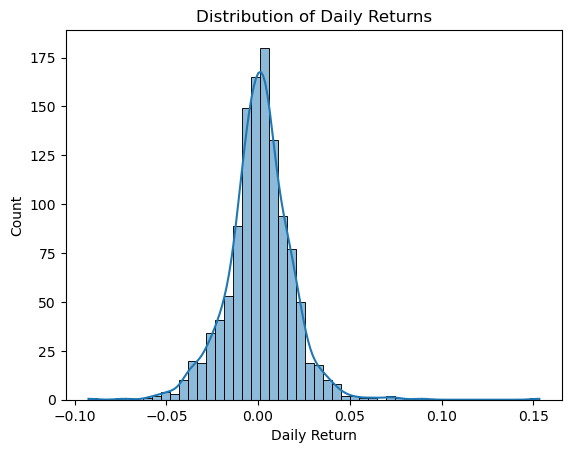

In [45]:
df['Daily_Return'] = df['Close'].pct_change()
sns.histplot(df['Daily_Return'].dropna(), bins=50, kde=True)
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.show()


In [47]:
print("Skewness:", df['Daily_Return'].skew())
print("Kurtosis:", df['Daily_Return'].kurt())


Skewness: 0.45376581454260656
Kurtosis: 6.402157213066733


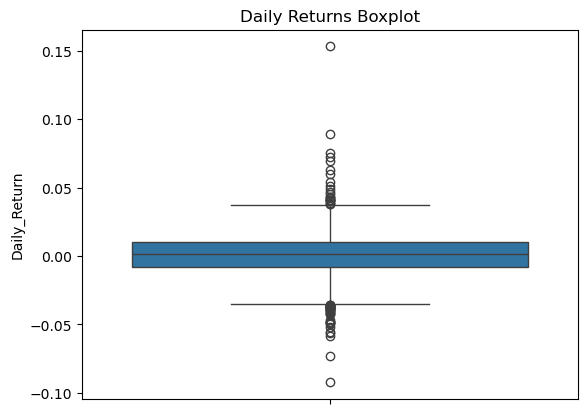

In [51]:
# Boxplot
sns.boxplot(y=df['Daily_Return'].dropna())
plt.title('Daily Returns Boxplot')
plt.show()